# Final implementation of the CNN matching algorithm including image classification

steps to get a ranking:
1. import all necassary modules
2. set all dataset directories
3. run functions for calculating similarities
4-5 only if using image classifying
4. run munchen classifying code only if image_categories.csv IS NOT present in directory
5. run function for classifying nk image
6. set nk_image filename (can be done in get similarities code)
7. run get similarities code. image classification can be turned off here
8. run functions for showing ranking
9. run ranking visualisation

this will result in the ranking
when you want to do this for a different nk image you only have to repeat steps 6,7 and 9

all necessary imports. python 3.10.10 used. all packages need to be installed for the code to work


In [23]:
import pandas as pd
import os
import cv2
import torch
from torchvision import models
from torchvision.models import resnet50, ResNet50_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
import csv
base_dir = os.getcwd()

Directories for datasets. Choose between paintings and furniture by commenting out the other

In [2]:
munich_dataset_directory = 'scraped_images_grayscaled_big'

# nk datasets for paintings 
nk_dataset_directory = 'nk_collection_paintings_cleaned'
nk_visual_directory = 'nk_collection_paintings'

# nk datasets for furniture 
# nk_dataset_directory = 'nk_collection_furniture_cleaned'
# nk_visual_directory = 'nk_collection_furniture'

functions to calculate similarities between images using inceptionv3 model

In [24]:
model = models.inception_v3(pretrained=True, aux_logits=True)
model.eval()


def preprocess_image(image_path):
    """
    Preprocesses a single image for InceptionV3 input.
    """
    # Read the image as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize to 299x299 for InceptionV3
    img = cv2.resize(img, (299, 299))
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    
    # Normalize to [0, 1]
    img = np.array(img, dtype=np.float32) / 255.0
    
    # Since the model expects 3 channels, we stack the grayscale image to create 3 channels
    img = np.stack([img, img, img], axis=-1)
    
    # Apply Gamma correction
    gamma = 1.2  # Example gamma value, adjust as necessary
    img = np.power(img, gamma)
    
    # Normalize with ImageNet mean and std
    img = (img - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    
    # Transpose to (channels, height, width)
    img = np.transpose(img, (2, 0, 1))
    
    # Add batch dimension
    img = np.expand_dims(img, axis=0)
    
    # Convert to PyTorch tensor with dtype float32
    img = torch.tensor(img, dtype=torch.float32)

    return img

def extract_features(image_path):
    """
    Extract features from a single image using InceptionV3.
    """
    img = preprocess_image(image_path)
    with torch.no_grad():
        features = model(img)
    return features.squeeze(0).numpy()

def normalize_features(features):
    """
    Normalize the extracted features.
    """
    return features / np.linalg.norm(features)

def compute_similarity(nk_img_feature_descriptor, munich_img_path):
    """
    Computes the similarity between two images
    """
    if not os.path.exists(munich_img_path):
        raise FileNotFoundError(f"Munich image file {munich_img_path} not found.")
    
    munich_img_feature_descriptor = normalize_features(extract_features(munich_img_path).flatten())
    similarity = np.dot(nk_img_feature_descriptor, munich_img_feature_descriptor)
    return similarity.item()

def compute_similarities_img_to_set(nk_img, munich_testset, munich_path="scraped_images_grayscaled_big", nk_path="nk_collection_paintings_cleaned", max_workers=6):
    """
    Computes the similarity of 1 (NK) image with an entire set of images (MCCP)
    """
    similarities = {}
    counter = 0
    nk_img_path = os.path.join(nk_path, nk_img)
    
    # Ensure the NK image file exists
    if not os.path.exists(nk_img_path):
        raise FileNotFoundError(f"NK image file {nk_img_path} not found.")
    
    nk_img_feature_descriptor = normalize_features(extract_features(nk_img_path).flatten())
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_munich_img = {executor.submit(compute_similarity, nk_img_feature_descriptor, os.path.join(munich_path, munich_img)): munich_img for munich_img in munich_testset}
        
        for future in as_completed(future_to_munich_img):
            munich_img = future_to_munich_img[future]
            try:
                similarity = future.result()
                similarities[(nk_img, munich_img)] = similarity
            except Exception as exc:
                print(f"Munich image {munich_img} generated an exception: {exc}")
    
    return similarities

C:\Users\jacob\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\jacob\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


This is the code that was used to classify all images the munchen dataset. Doesnt need to be run when image_categories.csv is already present. When this file is lost, this code can be run to reclassify everything. This will take around 60 minutes depending on hardware. A new image_categories.csv will then be created.

In [25]:
# load classifying model
weights = ResNet50_Weights.DEFAULT
model_class = resnet50(weights=weights)
model_class.eval()

preprocess = weights.transforms()
labeled_list = [[]]

# get prediction of every image in munchen dataset
for file in os.listdir(munich_dataset_directory):
    image = Image.open(os.path.join(munich_dataset_directory, file)).convert('RGB')
    batch = preprocess(image).unsqueeze(0)

    prediction = model_class(batch).squeeze(0).softmax(0)
    class_id = prediction.argmax().item()
    score = prediction[class_id].item()
    category_name = weights.meta["categories"][class_id]
    labeled_list += [file, category_name]

combined_list = []

# Iterate through the list starting from the second item, in steps of 2
for i in range(1, len(labeled_list) - 1, 2):
    combined_list.append([labeled_list[i], labeled_list[i + 1]])

# If the list length is odd, we need to handle the last item
if len(labeled_list) % 2 == 0:
    combined_list.append([labeled_list[-2], labeled_list[-1]])
else:
    combined_list.append([labeled_list[-3], labeled_list[-2]])

my_df = pd.DataFrame(combined_list)

# store list of image filenames with classes into a csv
my_df.to_csv('image_categories.csv', index=False, header=False)


KeyboardInterrupt: 

Function to classify one image from nk collection. returns category.

In [26]:
def classify_image(img_name):
    image = Image.open(os.path.join(nk_dataset_directory, img_name)).convert('RGB')

    # Initialize model 
    weights = ResNet50_Weights.DEFAULT
    model_class = resnet50(weights=weights)
    model_class.eval()

    preprocess = weights.transforms()
    batch = preprocess(image).unsqueeze(0)

    # predict class
    prediction = model_class(batch).squeeze(0).softmax(0)
    class_id = prediction.argmax().item()
    category_name = weights.meta["categories"][class_id]
    
    return category_name

In [27]:
# get similarity scores
def get_similarities(nk_image, image_class=True, munich_path=munich_dataset_directory, nk_path=nk_dataset_directory):
    
    # get images from munchen dataset with the same class as nk image
    if image_class:
        nk_category = classify_image(nk_image)
        print('class: ', nk_category)

        munich_set = []

        with open('image_categories.csv', newline='') as csvfile:

            img_reader = csv.reader(csvfile, delimiter=',', quotechar='|')

            for row in img_reader:
                if row[1] == nk_category:
                    munich_set += [row[0]]
    # get all images from the munchen dataset
    else:
        munich_set = os.listdir(munich_path)

    print('class size:', len(munich_set))
    print('running...')

    # get and return similarities
    sims = compute_similarities_img_to_set(nk_image, munich_set, munich_path=munich_path ,nk_path=nk_path)
    print('done')
    return sims

# set nk image filename here
nk_img = ("schilderij_162.jpg")

# get similarities 
# image_class = True for fast algorithm. False for full search
similarities = get_similarities(nk_img, image_class=True)

class:  hoopskirt
class size: 571
running...
done


Funtions for showing ranking

In [28]:
def rank_similarities(similarities, ranking_size):
    """
    Get a ranking of the highest similarity values for each NK image from the similarities dictionary.
    
    Parameters:
    - similarities: A dictionary where keys are (NK image name, Munich image name) tuples
                    and values are similarity scores.
                    
    Returns:
    - A dictionary where keys are NK image names and values are lists of tuples
      (Munich image name, similarity) sorted by similarity in descending order.
    """
    top_similarities = {}
    
    for nk_img_name in set(key[0] for key in similarities.keys()):
        # Filter similarities for current NK image
        nk_similarities = [(munich_img_name, similarity) for (nk, munich_img_name), similarity in similarities.items() if nk == nk_img_name]
        
        # Sort by similarity in descending order
        sorted_similarities = sorted(nk_similarities, key=lambda x: x[1], reverse=True)
        
        # Get top similarities
        top_similarities[nk_img_name] = sorted_similarities[:ranking_size]
    
    return top_similarities

def display_image(image_path):
    image = imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

def display_nk_image(nk_img_name):
    image_path = nk_visual_directory + '/' + nk_img_name
    image = imread(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

Ranking visualisation

Ranking of images similar to NK image 'schilderij_162.jpg':


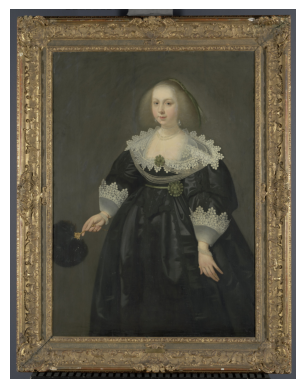

Rank 1: Munich image '1206_9230_id=cp131036_linz.jpg' (Similarity: 0.7465656995773315):


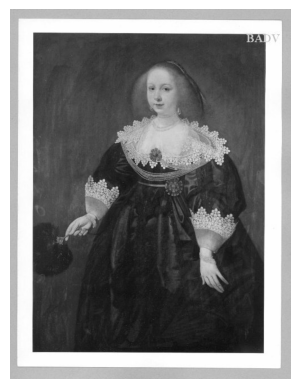

Rank 2: Munich image '1206_9230_id=cp175854_badv.jpg' (Similarity: 0.6913451552391052):


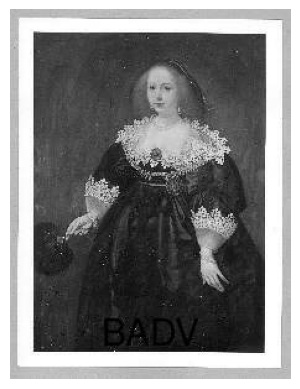

Rank 3: Munich image '0388_1750_id=cp145044_badv.jpg' (Similarity: 0.6864407658576965):


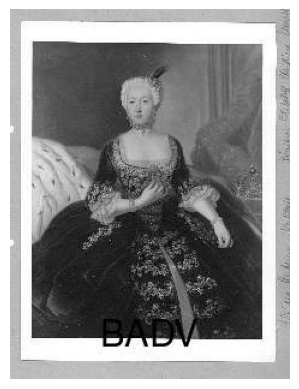

Rank 4: Munich image '0737_4457_id=cp132013_linz.jpg' (Similarity: 0.6750370264053345):


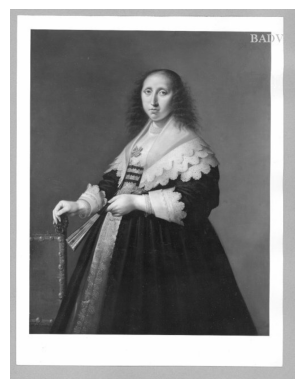

Rank 5: Munich image '0737_4455_id=cp132138_linz.jpg' (Similarity: 0.6588035225868225):


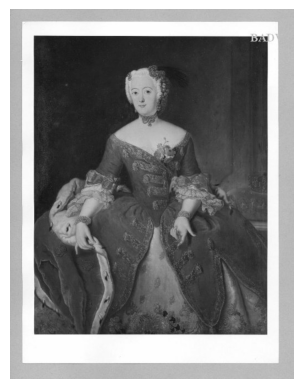

Rank 6: Munich image '0879_5839_id=cp169218_badv.jpg' (Similarity: 0.6416001319885254):


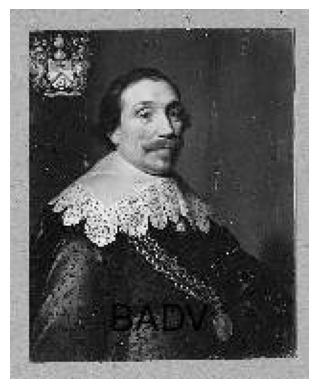

Rank 7: Munich image '2217_45070_id=cp132850_linz.jpg' (Similarity: 0.6356228590011597):


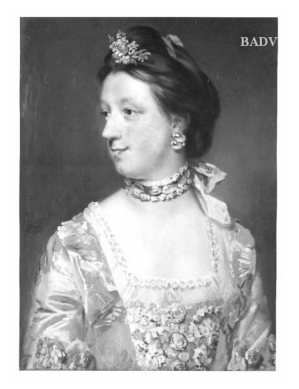

Rank 8: Munich image '0737_4455_id=cp162977_badv.jpg' (Similarity: 0.628447413444519):


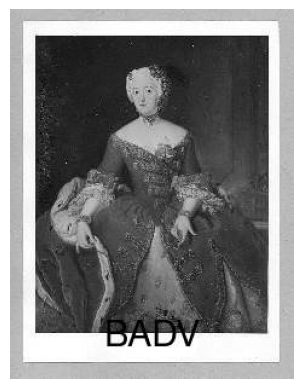

Rank 9: Munich image '0388_1750_id=cp130630_linz.jpg' (Similarity: 0.6248841881752014):


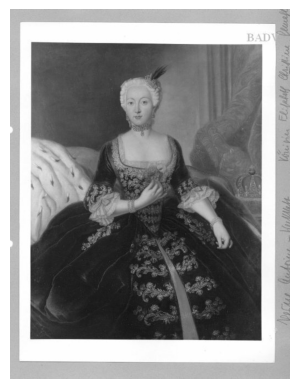

Rank 10: Munich image '0741_4486_id=cp163290_badv.jpg' (Similarity: 0.6219937205314636):


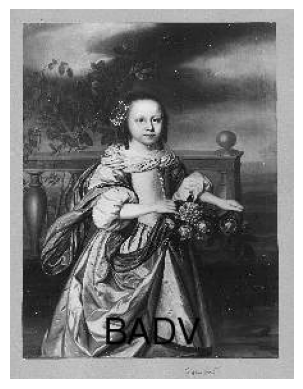

Rank 11: Munich image '1146_8616_id=cp174862_badv.jpg' (Similarity: 0.6154728531837463):


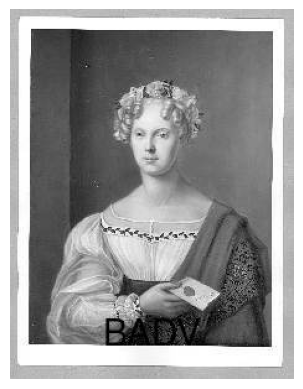

Rank 12: Munich image '1356_11239_id=cp133838_linz.jpg' (Similarity: 0.613049328327179):


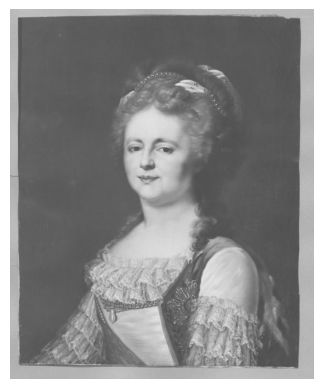

Rank 13: Munich image '0049_179-2_id=cp145539_badv.jpg' (Similarity: 0.6080136299133301):


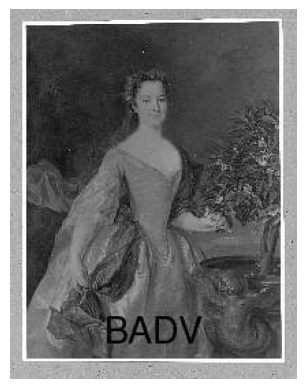

Rank 14: Munich image '0604_2988_id=cp131467_linz.jpg' (Similarity: 0.6076613068580627):


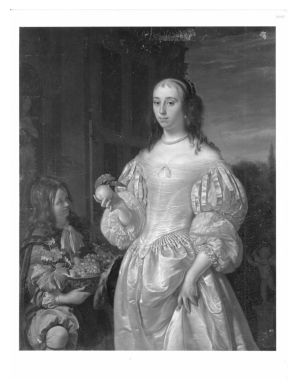

Rank 15: Munich image '1371_11415_id=cp130153_linz.jpg' (Similarity: 0.606065034866333):


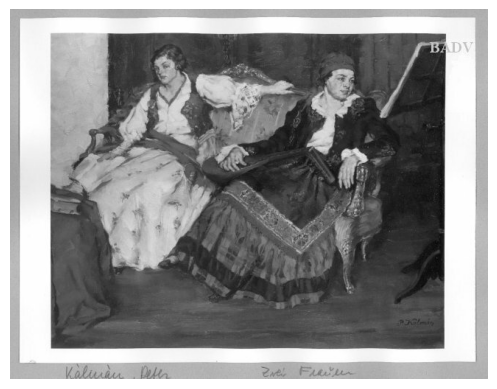

Rank 16: Munich image '2216_45070_id=cp163534_badv.jpg' (Similarity: 0.605588972568512):


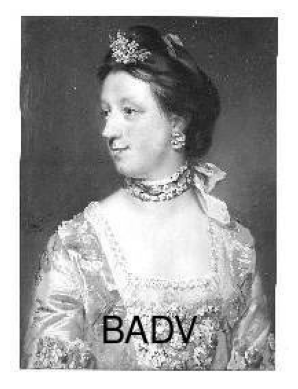

Rank 17: Munich image '0551_2621_id=cp131889_linz.jpg' (Similarity: 0.5988314747810364):


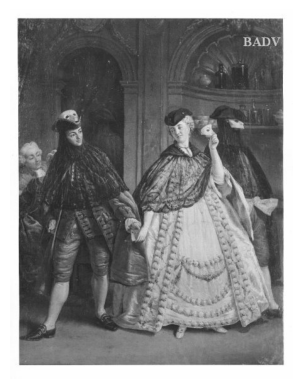

Rank 18: Munich image '0101_550-2_id=cp168653_badv.jpg' (Similarity: 0.5984470844268799):


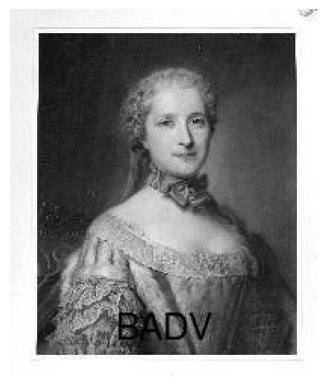

Rank 19: Munich image '0271_1458_id=cp131506_linz.jpg' (Similarity: 0.5972705483436584):


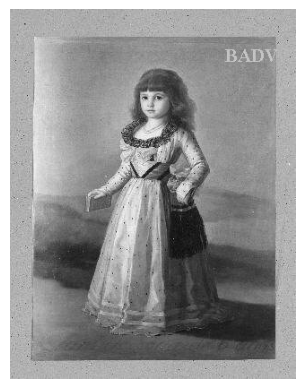

Rank 20: Munich image '0614_3075_id=cp154073_badv.jpg' (Similarity: 0.5888831615447998):


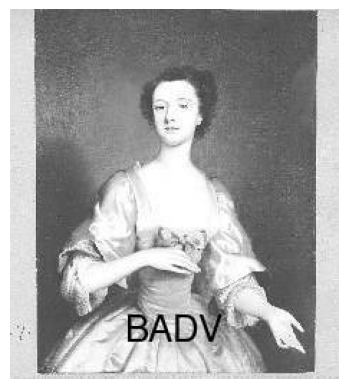

In [29]:
# pick ranking size and get ranking
ranking_size = 20
top_sims = rank_similarities(similarities, ranking_size)

# show ranking
rank = 1
for nk_img_name, similar_images in top_sims.items():
    print(f"Ranking of images similar to NK image '{nk_img_name}':")
    display_nk_image(nk_img_name)
    for munich_img_name, similarity in similar_images:
        image_path = munich_dataset_directory + '/' + munich_img_name
        print(f"Rank {rank}: Munich image '{munich_img_name}' (Similarity: {similarity}):")
        display_image(image_path)
        rank += 1